
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R5  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Basem Sameh/2025 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sb

%matplotlib inline

In [3]:
# Load my dataset using pandas Dataframe
df = pd.read_csv("fordgobike-tripdataFor201902.csv")


In [4]:
# here we make overview in high-level for data shape and composition
df.shape


(183416, 16)

In [5]:
## check each var  datatype 
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtypes": dtypes, "Uniqe_Numbers": n_uniq}).T


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
Dtypes,int64,str,str,float64,str,float64,float64,float64,str,float64,float64,int64,str,float64,str,str
Uniqe_Numbers,4752,35783,35767,329,329,334,335,329,329,335,335,4646,2,75,3,2


In [6]:
## I display 15 rows to understand the content values more 

df.head(15)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [7]:
# descriptive statistics for numeric variables
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000




> ### What is the structure of your dataset?





- The structure of the dataset contains  183416 columns and 16 rows.
 
 
- Most variables are ...... in nature , and here are **dtypes summary :**

        - str (7)
        - int64 (2)
        - float64 (7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
- start_time --> show which time is a rush hour
 
 
 
- start_station_name --> show which station have a heigher order
 
  
 
  
- duration_sec --> shows the trip duration, and it will be used for a lot of analysis later




> ### What features in the dataset supported my investigation for these interesting features?



- end_time --> help us with start_time feature to anyls the trip time and duration 



- end_station_name --> help us with start_station_name feature to determine the route of trip between stations.



- user_type --> We can see if the duration of the journey or the choice of stations differs depending on the type of user.



- member_gender --> We can compare the duration of journeys and station usage between genders.




- member_birth_year --> We can correlate the duration of the trip and usage behavior with the user's age.




##  More Exploring ideas to begin my investigation

In [8]:
#This code for describing statistical data ideas in a more organized and readable table
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_sec,183416.0,726.067311,1794.371831,61.000000,325.000000,514.000000,796.000000,85444.000000
start_station_id,183219.0,138.590365,111.778938,3.000000,47.000000,104.000000,239.000000,398.000000
start_station_latitude,183416.0,37.771221,0.099586,37.317298,37.770083,37.780760,37.797280,37.880222
start_station_longitude,183416.0,-122.352661,0.117100,-122.453705,-122.412408,-122.398285,-122.286533,-121.874119
end_station_id,183219.0,136.249401,111.514916,3.000000,44.000000,100.000000,235.000000,398.000000
end_station_latitude,183416.0,37.771425,0.099494,37.317298,37.770407,37.781010,37.797320,37.880222
end_station_longitude,183416.0,-122.352247,0.116677,-122.453705,-122.411726,-122.398279,-122.288045,-121.874119
bike_id,183416.0,4472.890260,1664.386068,11.000000,3777.000000,4958.000000,5502.000000,6645.000000
member_birth_year,175151.0,1984.806504,10.116589,1878.000000,1980.000000,1987.000000,1992.000000,2001.000000


In [9]:
# display the information about each column
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [10]:
#yOUR CODES
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64



> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with Mean for numeric and median for categorical

In [11]:
# trying to fill missing values in my datset using for loop 
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)

In [12]:
#check the Nulls 
df.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year             0
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

### **And with a proper category for other (member gender)**

In [13]:
##  still got a missing value in the member_gender, so let's explore this column more 

#   print(gbf.member_gender.head(15))
df.member_gender.head(15)

0       Male
1        NaN
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13       NaN
14      Male
Name: member_gender, dtype: str

In [14]:
# fill  dataset with missing values.
df['start_station_name'] = df['start_station_name'].fillna('Unknown')
df['end_station_name'] = df['end_station_name'].fillna('Unknown')
df['member_gender'] = df['member_gender'].fillna('Other')


In [15]:
# print(gbf.member_gender.head(15))
df.member_gender.head(15)

0       Male
1      Other
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13     Other
14      Male
Name: member_gender, dtype: str

In [16]:
## check my result above 
df.isnull().sum()


duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [17]:
##  check duplicate in dataset
df.duplicated().sum()

np.int64(4)

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [18]:
### check the category columns that included object
df.select_dtypes(include='object').columns

C:\Users\loq\AppData\Local\Temp\ipykernel_32888\4026129391.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['start_time', 'end_time', 'start_station_name', 'end_station_name',
       'user_type', 'member_gender', 'bike_share_for_all_trip'],
      dtype='str')

 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [19]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')


In [20]:
## check your work 
df[['user_type', 'member_gender']].dtypes


user_type        category
member_gender    category
dtype: object

In [21]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year
df['age'] = 2019 - df['member_birth_year']

In [22]:
## check your work 
df['age'].head()

0    35.000000
1    34.193496
2    47.000000
3    30.000000
4    45.000000
Name: age, dtype: float64

In [23]:
## change the new column age data type from float to int
df['age'] = df['age'].astype(int)
df['age'].head()

0    35
1    34
2    47
3    30
4    45
Name: age, dtype: int64

In [24]:
## create a function to know the average users ages
def Avg_Age():
    avg_age = df['age'].mean()
    return avg_age
Avg_Age()

np.float64(34.18477668251407)

In [25]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable
df['duration_min'] = df['duration_sec'] / 60



In [26]:
## I need to change the time from second to Houre  to be more usable

df['duration_hrs'] = df['duration_sec'] / 3600


In [27]:
## check your work 
df[['duration_sec', 'duration_min', 'duration_hrs']].head()

,duration_sec,duration_min,duration_hrs
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

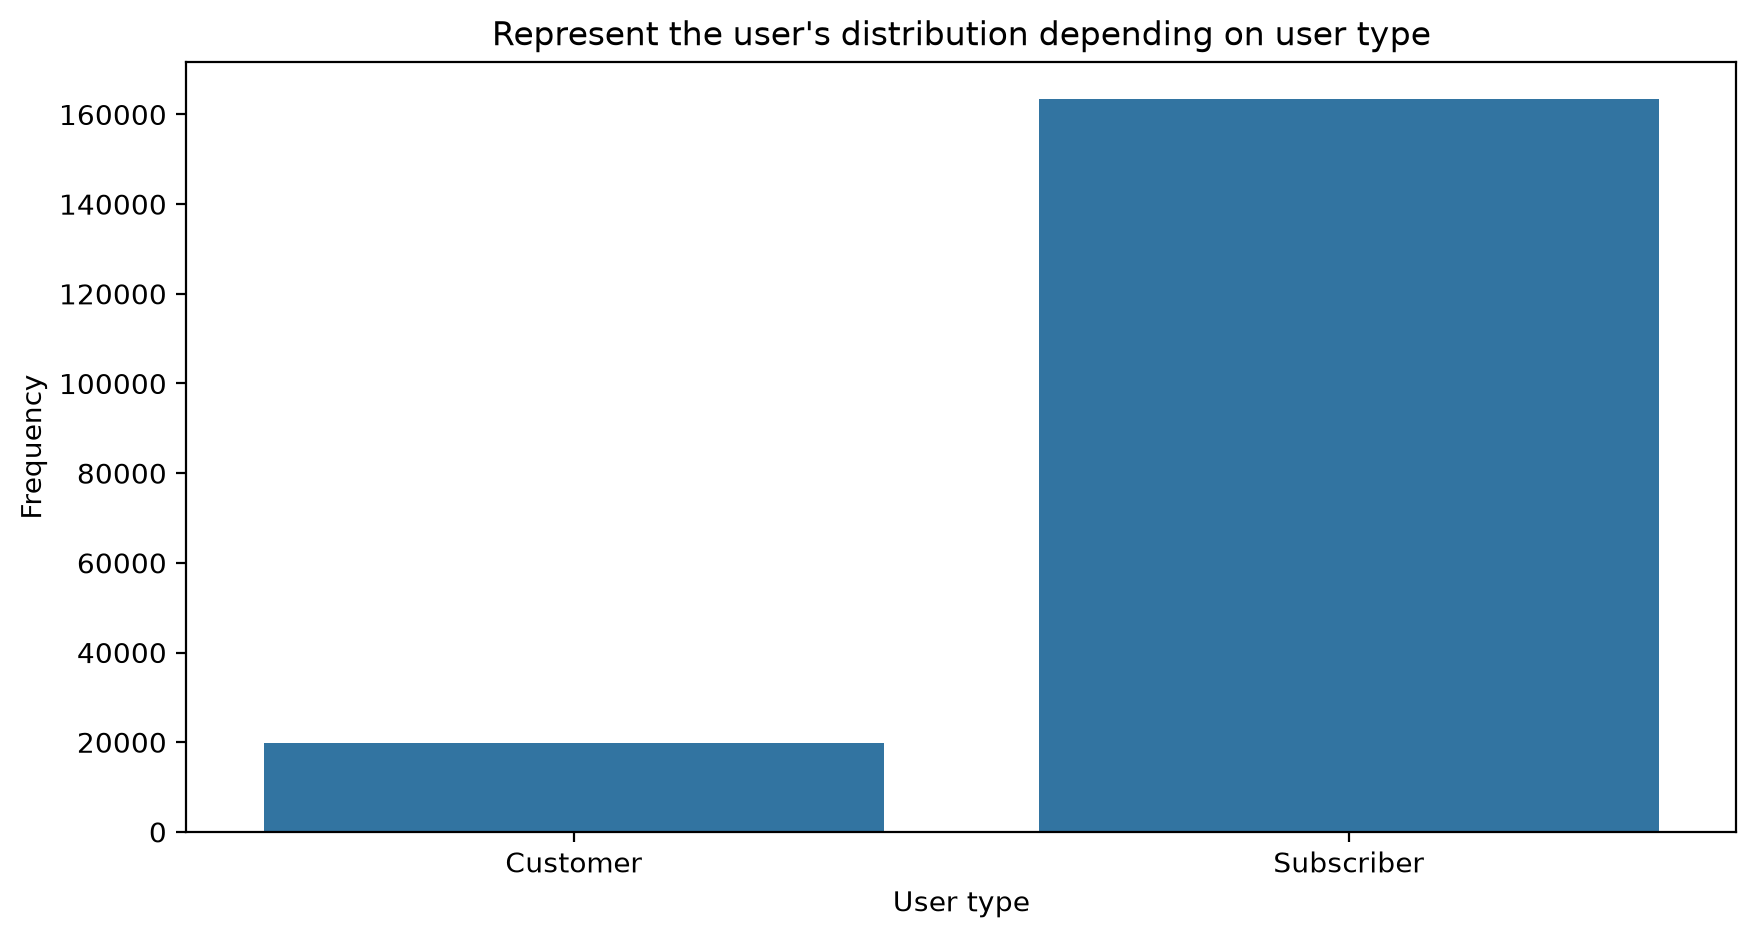

In [28]:

import seaborn as sns
plt.figure(figsize = (10,5), dpi = 200)

plot = sns.countplot(data=df, x='user_type')

plt.xlabel('User type')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on user type")

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    Most users are Subscribers, while Customers represent a smaller proportion of the users.

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

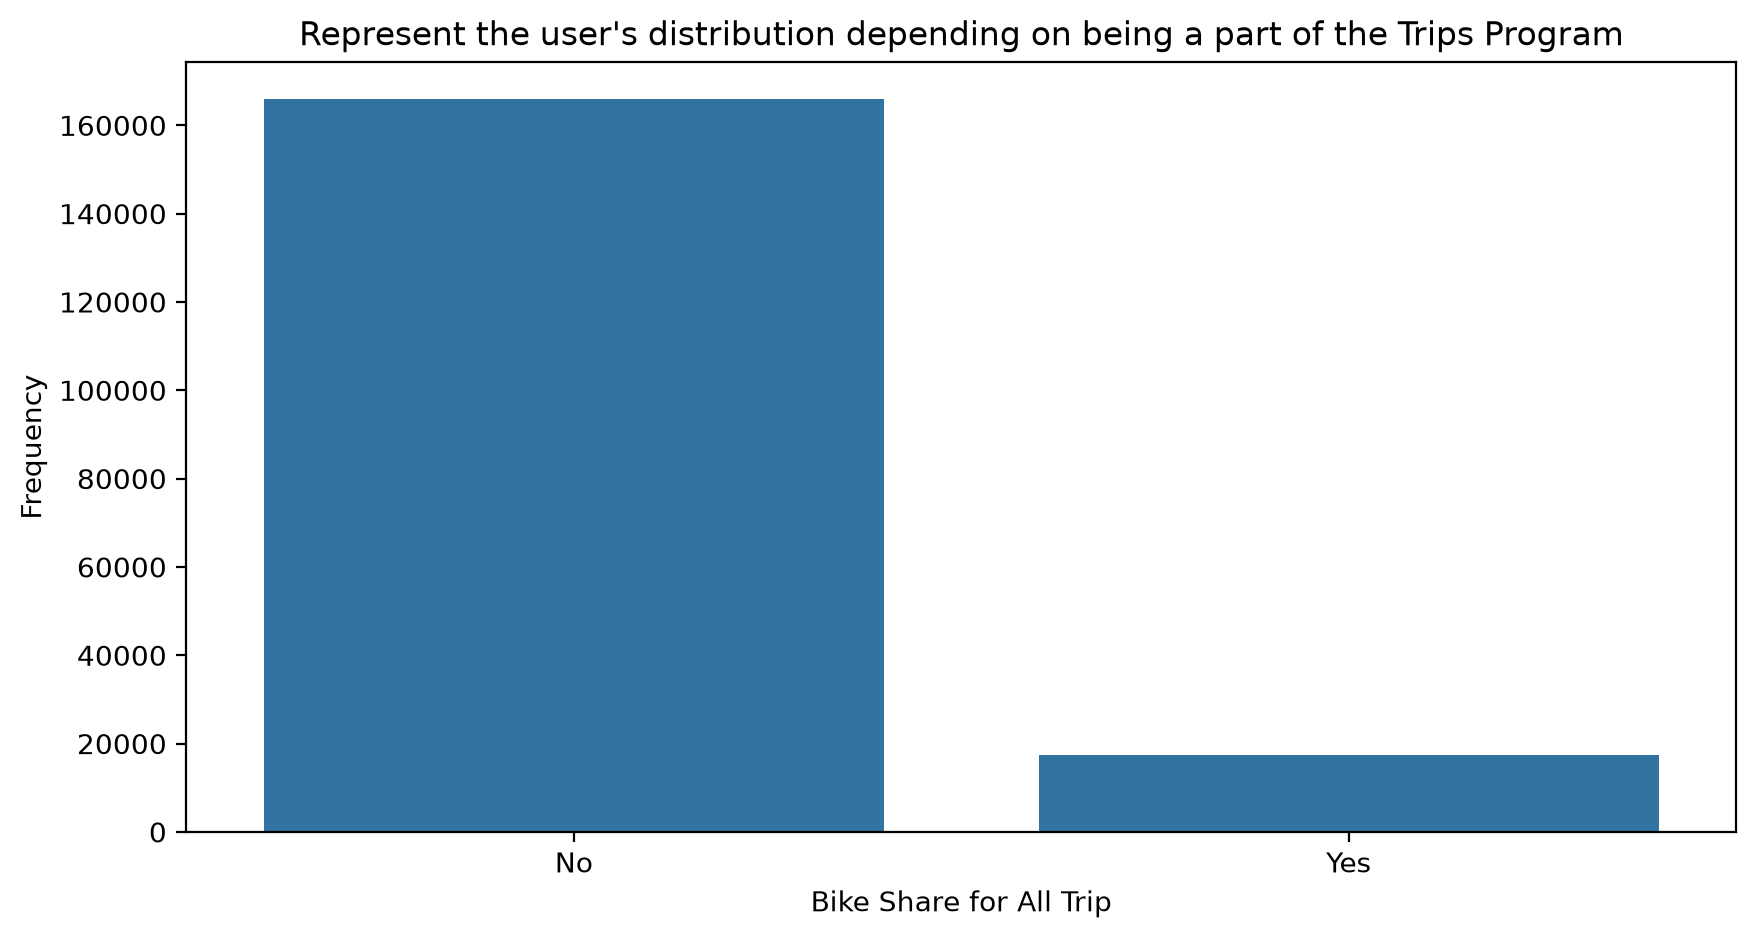

In [29]:
plt.figure(figsize = (10,5), dpi = 200)

plot = sns.countplot(data=df, x='bike_share_for_all_trip')

plt.xlabel('Bike Share for All Trip')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    Most users are not a part of the Bike Share for All Trip program, while the minority of users are enrolled in it

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

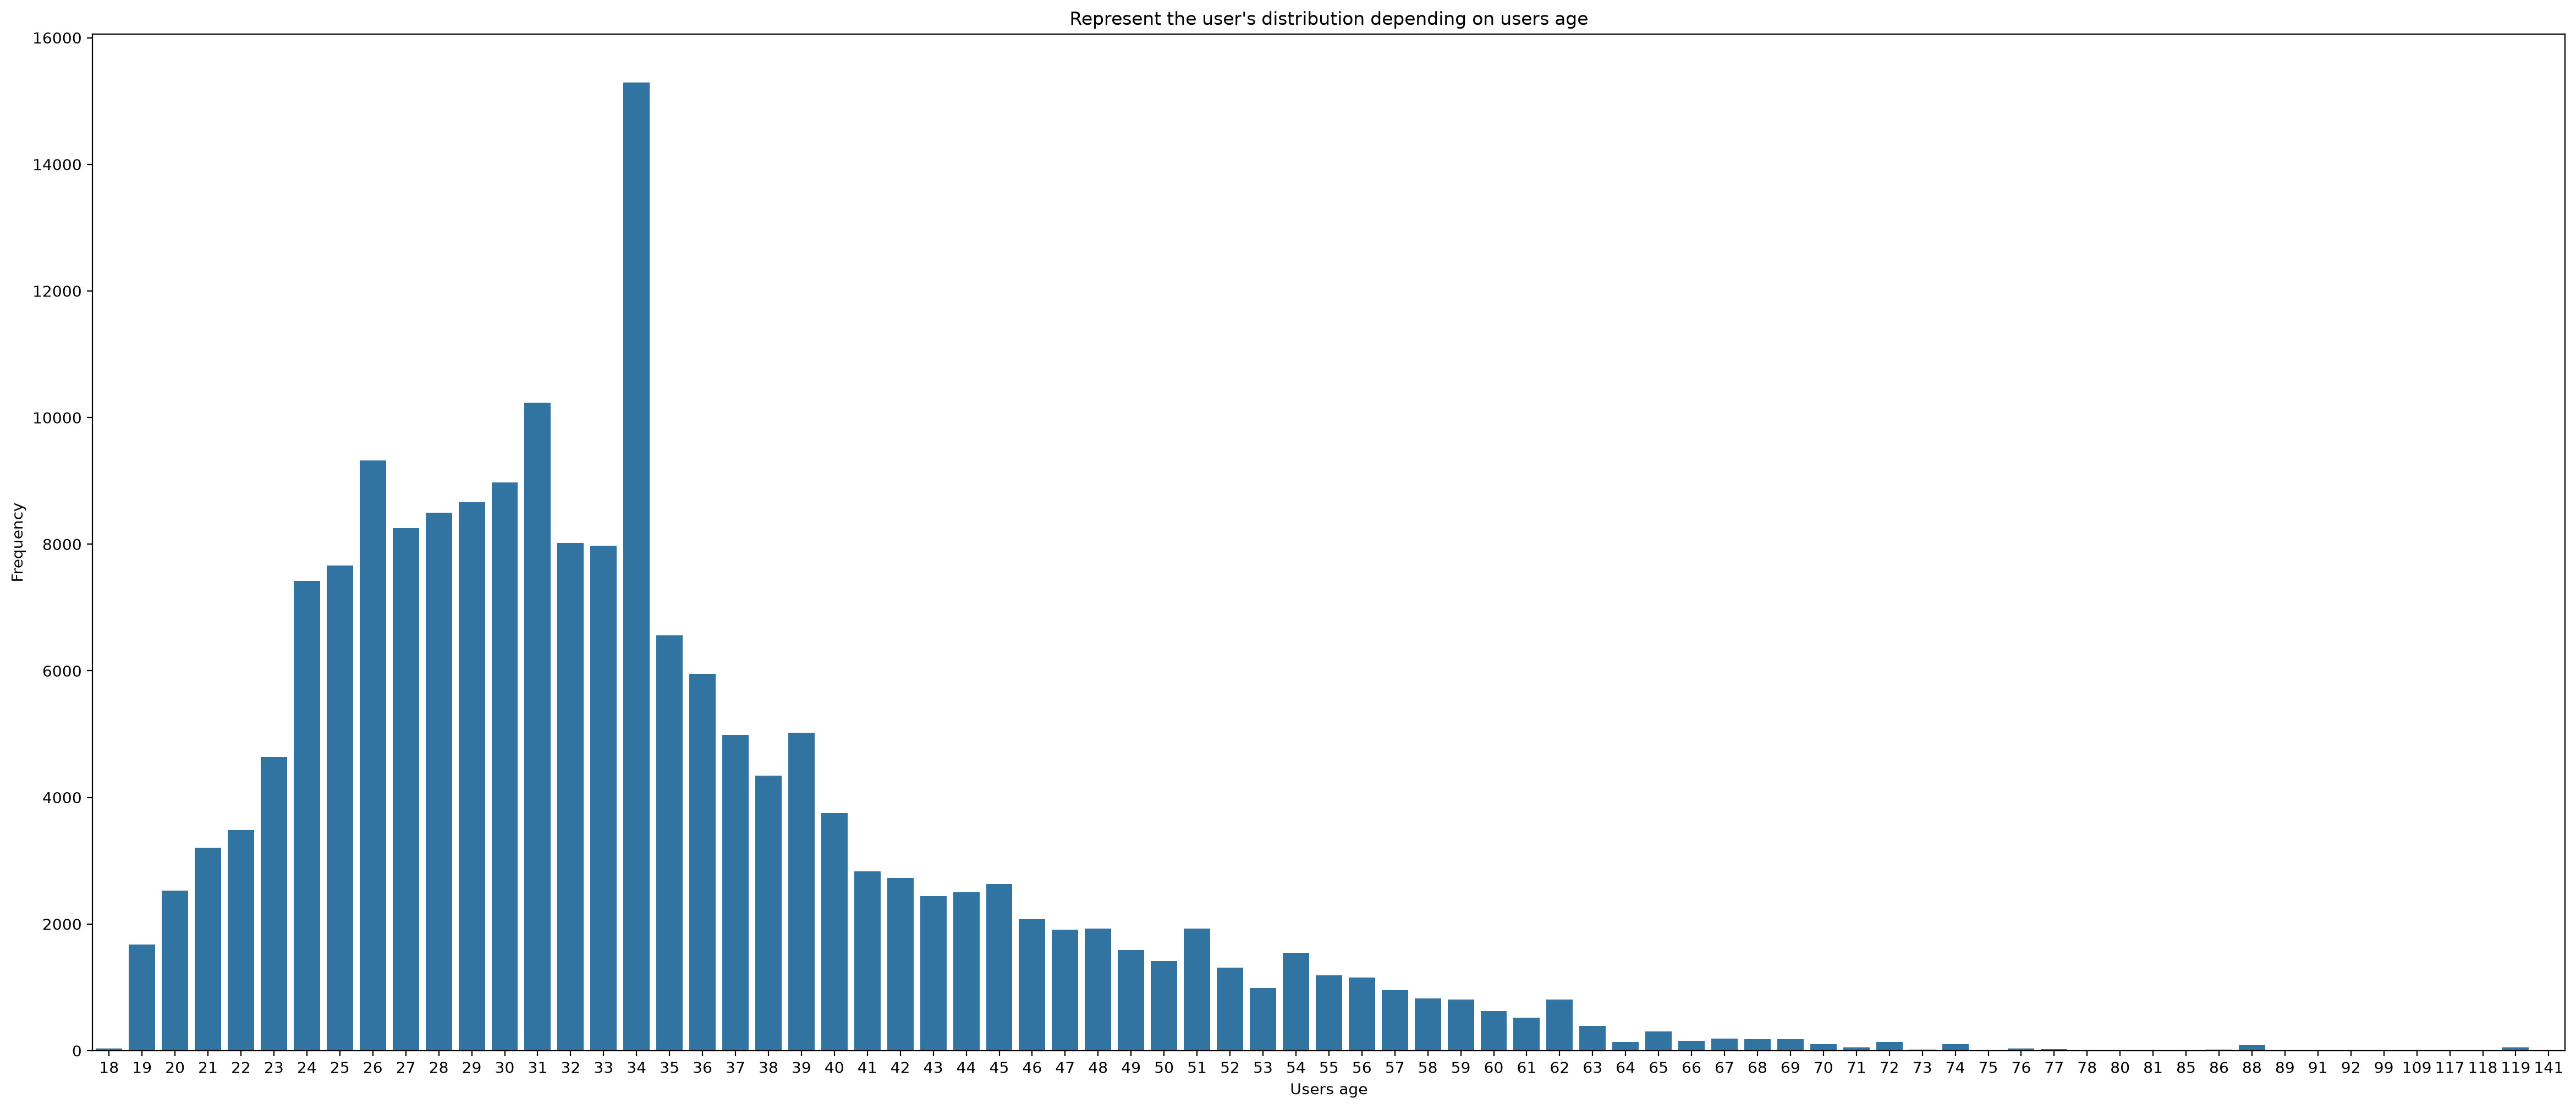

In [54]:
plt.figure(figsize = (29,12), dpi = 200)

plot = sns.countplot(data=df, x='age')
plt.xlabel('Users age')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on users age")

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    The most common age is 31 years, while the number of users generally decreases at older ages.


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


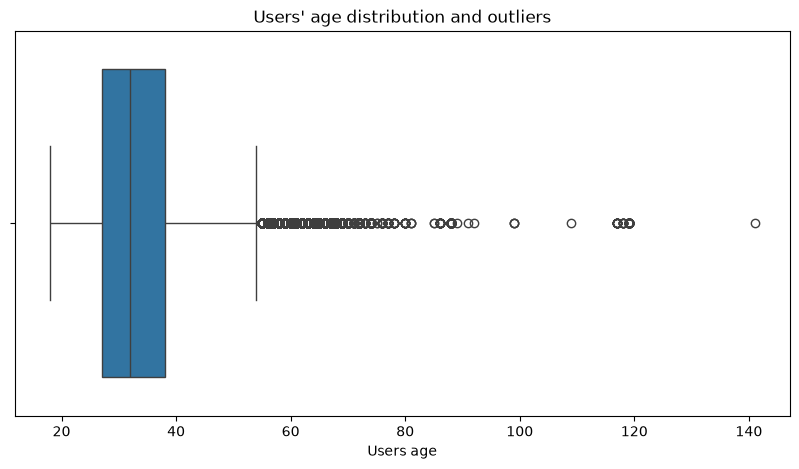

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='age')
plt.xlabel('Users age')
plt.title("Users' age distribution and outliers")

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    Yes, there are outlier values in users' ages. Most users are between 30 and 60 years old, while some ages above 60 are considered outliers.

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [32]:
## Review the statistic for trip duration in minutes
df['duration_min'].describe()

count    183416.000000
mean         12.101122
std          29.906197
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: duration_min, dtype: float64

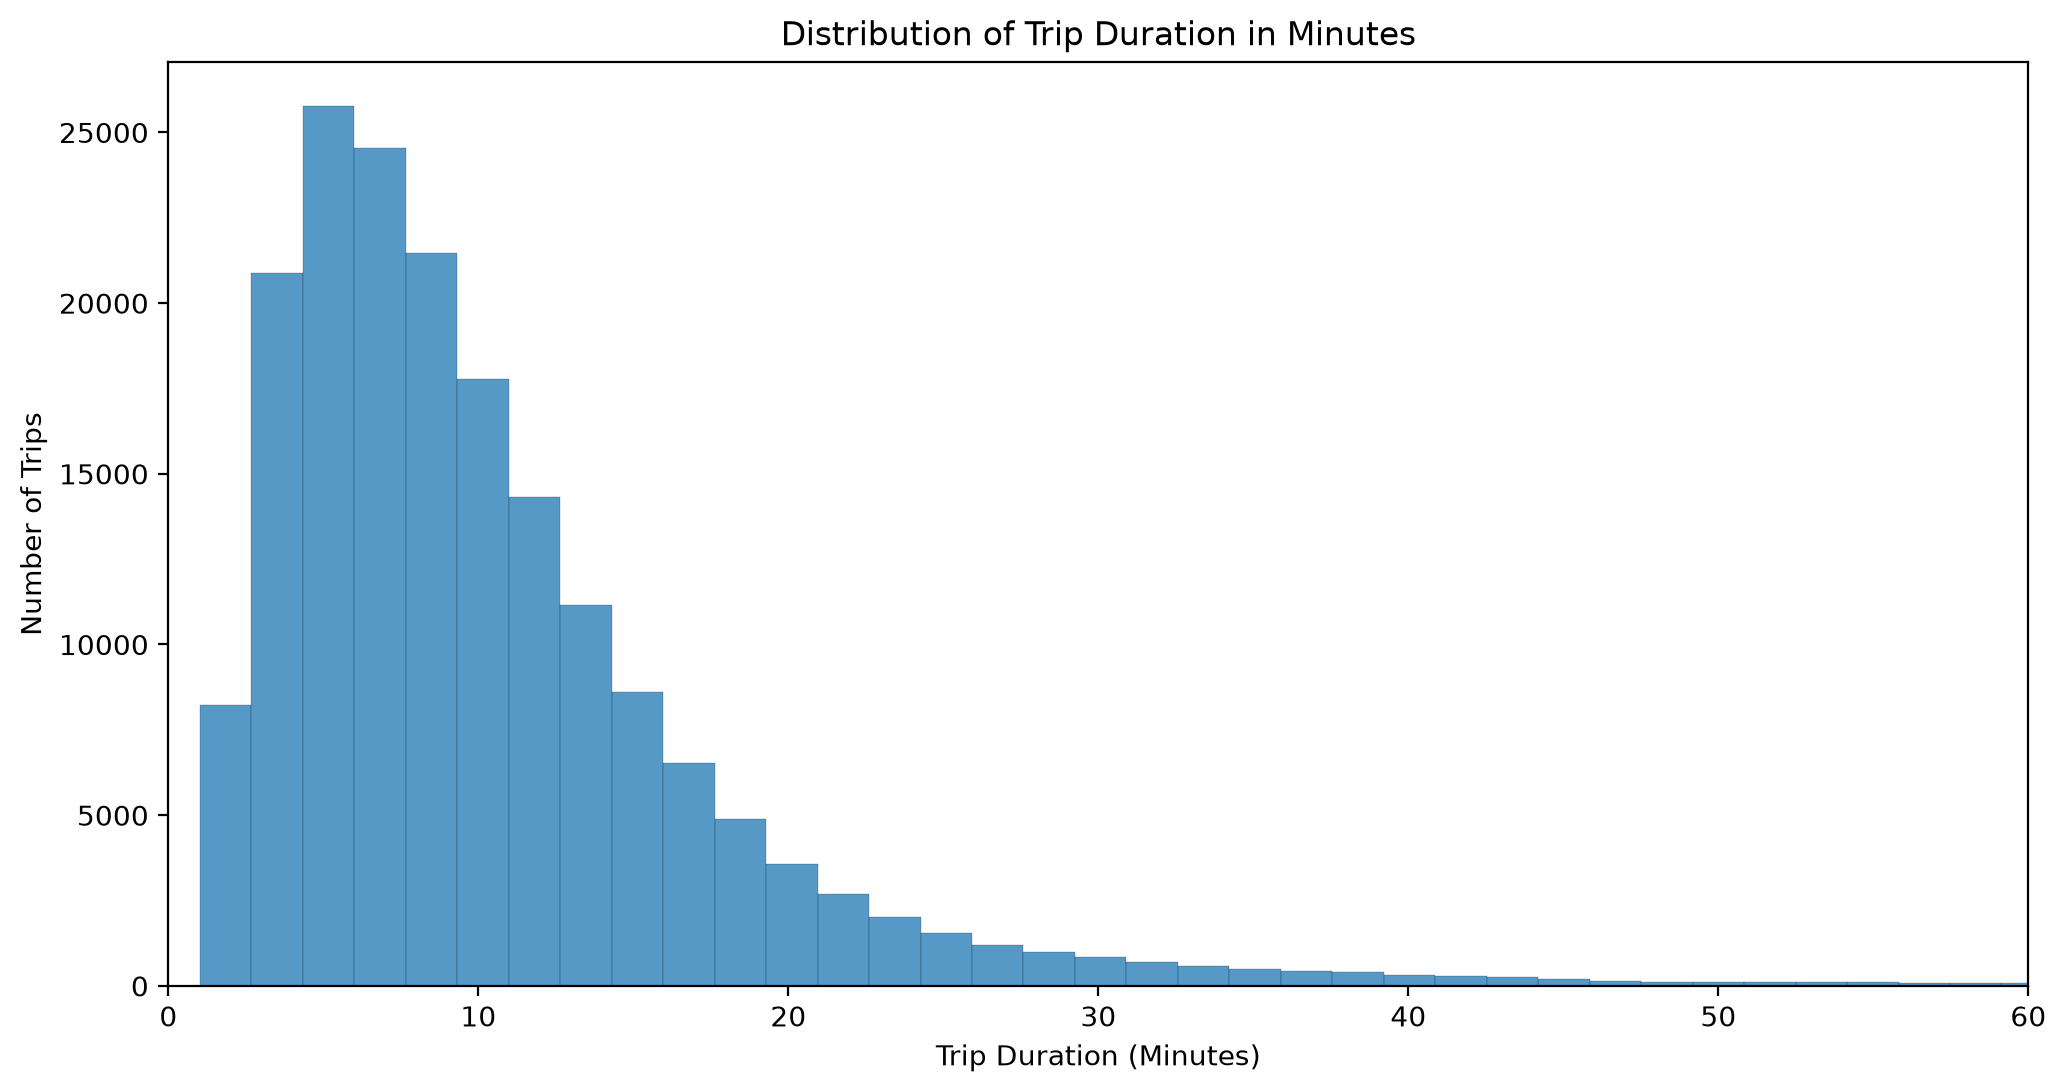

In [ ]:
# Make visualization to easy get insight
plt.figure(figsize = (12, 6), dpi = 200)

sns.histplot(data=df, x='duration_min')
plt.xlim(0, 60)

plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration in Minutes')

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    Most trips have a short duration. The distribution is right-skewed, with a small number of trips having much longer durations. The visualization focuses on the first 60 minutes to make the distribution of most trips clearer, while the longer trips are still present in the dataset.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

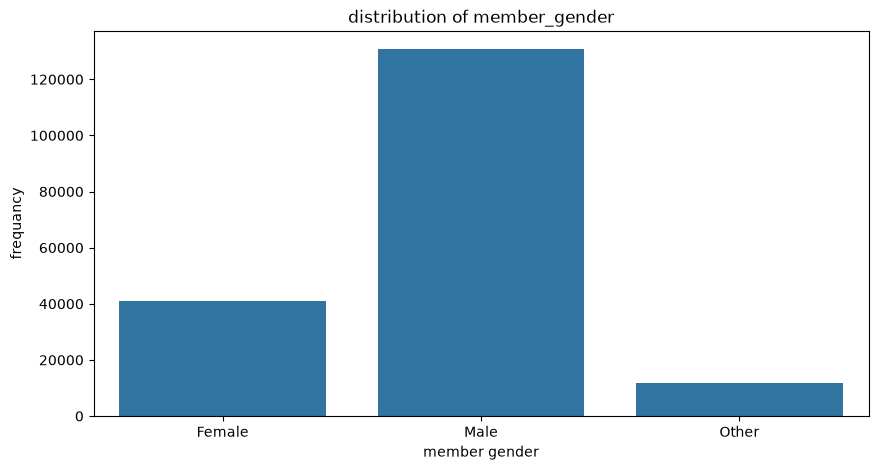

In [34]:
# Make visualization to easy get insight
plt.figure(figsize= (10, 5))
sns.countplot(data=df, x='member_gender')
plt.ylabel('frequancy')
plt.xlabel('member gender')
plt.title('distribution of member_gender')

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    Most users are male, followed by female users, while other users represent the smallest group.

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

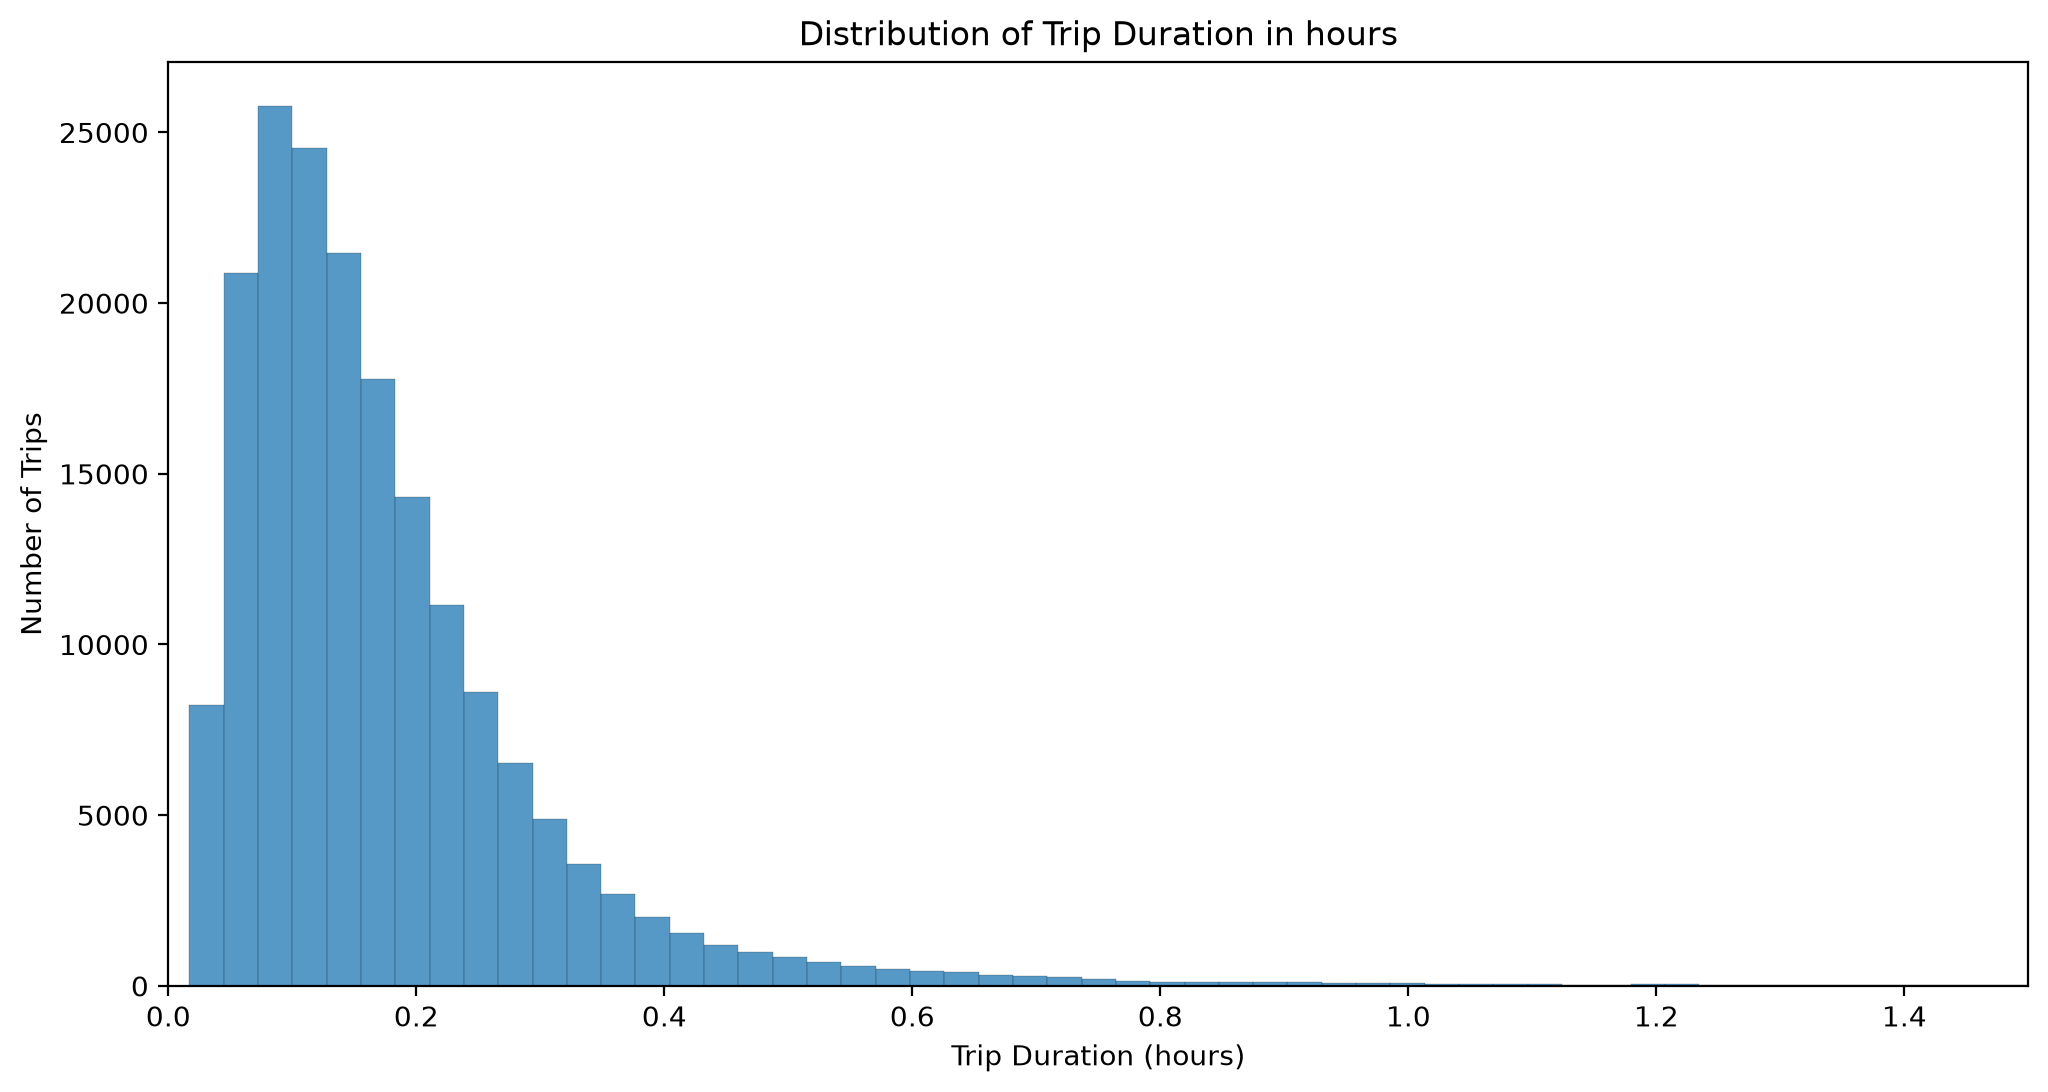

In [35]:
# Make visualization to easy get insight
plt.figure(figsize = (12, 6), dpi = 200)

sns.histplot(data=df, x='duration_hrs')
plt.xlim(0, 1.5)

plt.xlabel('Trip Duration (hours)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration in hours')

plt.show()

> ### <mark>Your analsys and exploration here </mark>
    Most trips have a short duration, while a small number of trips have much longer durations. The visualization focuses on the first 1.5 hours to make the distribution clearer, while longer trips are still present in the dataset.

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

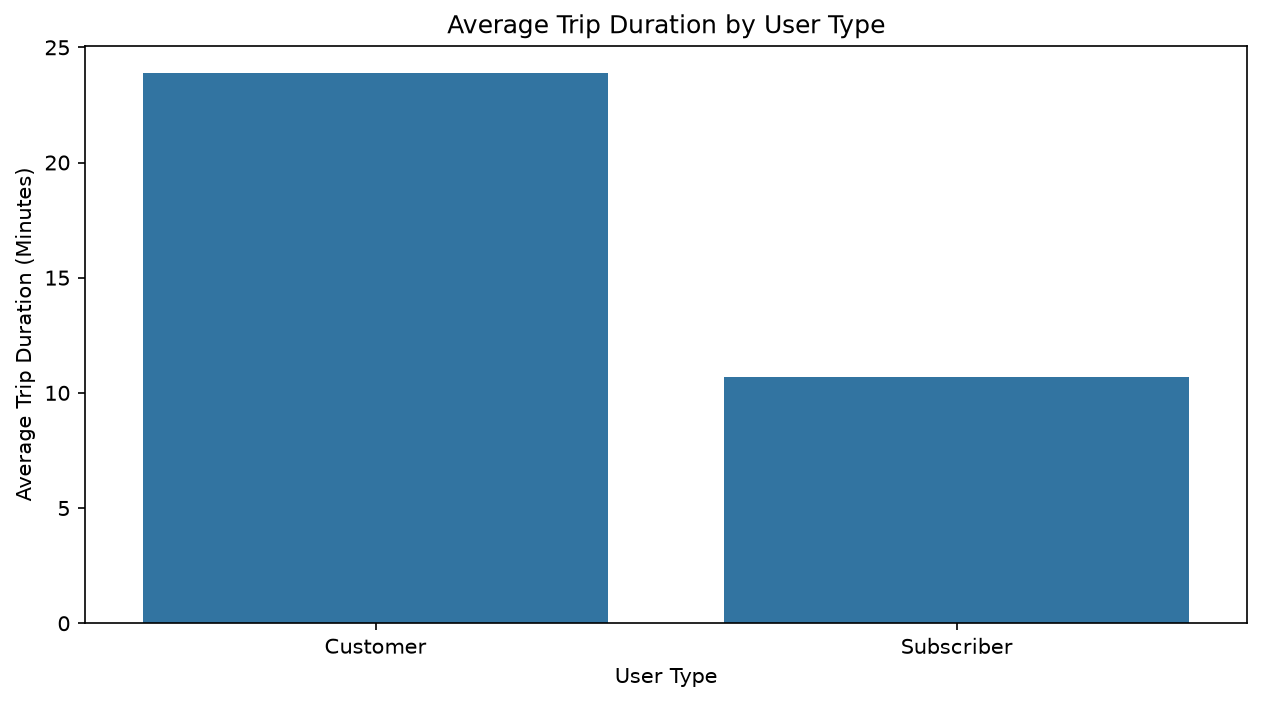

In [53]:
avg_duration_user_type = df.groupby('user_type')['duration_min'].mean()



plt.figure(figsize=(10, 5), dpi=150)

sns.barplot(
    x=avg_duration_user_type.index,
    y=avg_duration_user_type.values
)

plt.xlabel('User Type')
plt.ylabel('Average Trip Duration (Minutes)')
plt.title('Average Trip Duration by User Type')

plt.show()

# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>
    The average trip duration was calculated for each user type.
    The chart shows the difference in the average duration of trips between Subscribers and Customers.
    This helps us understand how the two user types use the bike-sharing service in terms of trip duration.

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

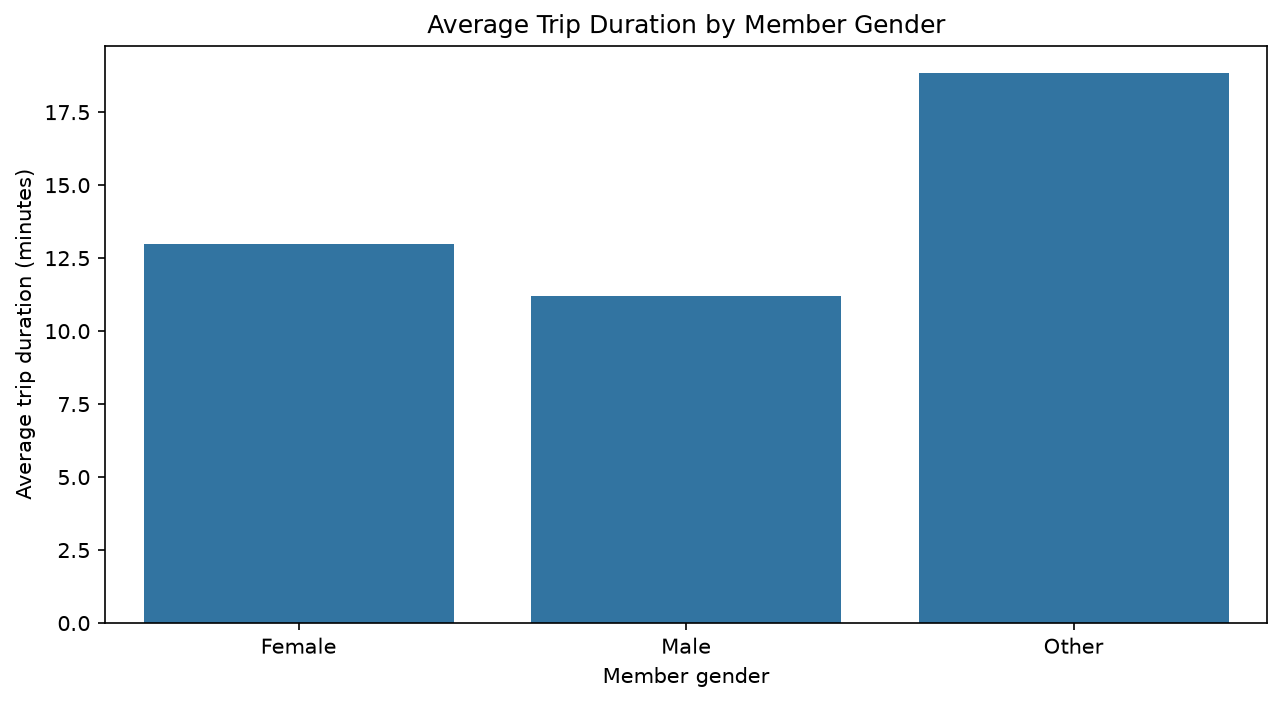

In [46]:
gender_duration = (
    df.groupby('member_gender', observed=True)['duration_min']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5), dpi=150)
sns.barplot(x=gender_duration.index, y=gender_duration.values)
plt.xlabel("Member gender")
plt.ylabel("Average trip duration (minutes)")
plt.title("Average Trip Duration by Member Gender")
plt.xticks(rotation=0)
plt.show()


> ### <mark>Your analsys and exploration here </mark>
    The average trip duration is calculated for each member gender using `duration_min The bar chart makes it easy to compare the average ride duration between Male, Female, and Other users.


# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

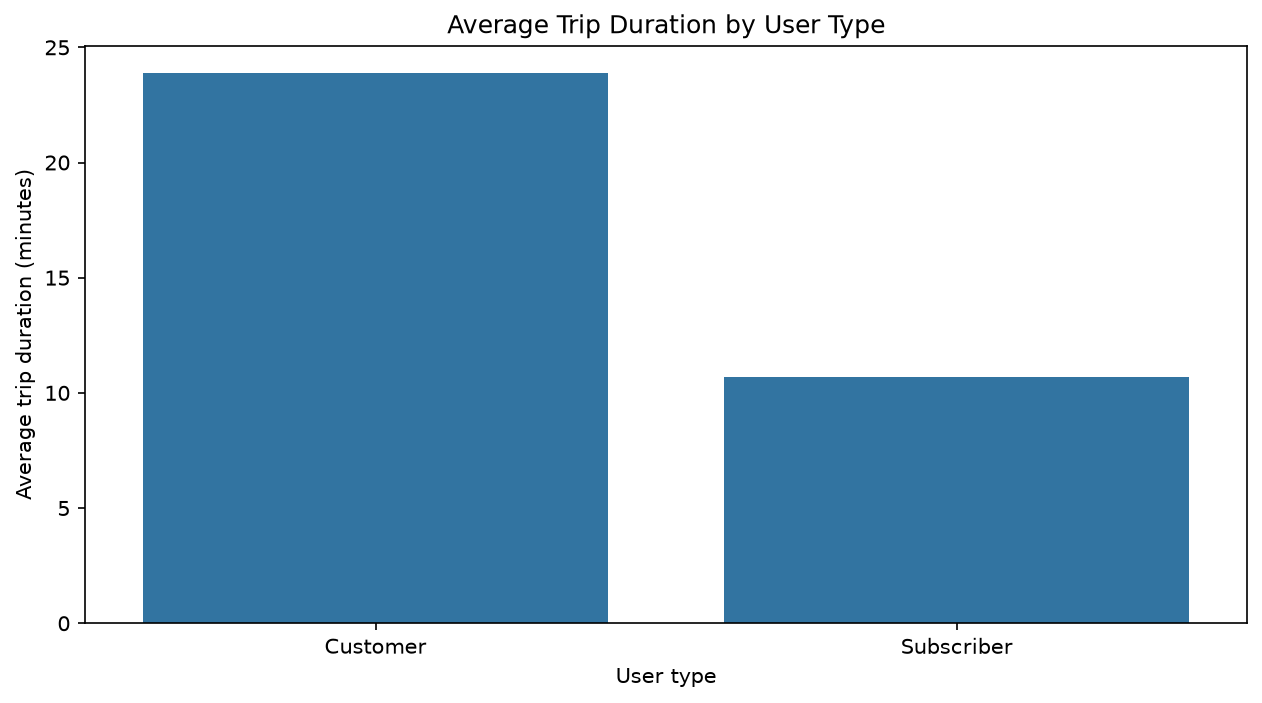

In [47]:
user_duration = (
    df.groupby('user_type', observed=True)['duration_min']
      .mean()
      .sort_values(ascending=False)
)


plt.figure(figsize=(10, 5), dpi=150)
sns.barplot(x=user_duration.index, y=user_duration.values)
plt.xlabel("User type")
plt.ylabel("Average trip duration (minutes)")
plt.title("Average Trip Duration by User Type")
plt.show()


> ### <mark>Your analsys and exploration here </mark>  
    The average trip duration is calculated for each `user_type` This comparison shows whether Customers and Subscribers use the bikes for different average ride durations.


# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

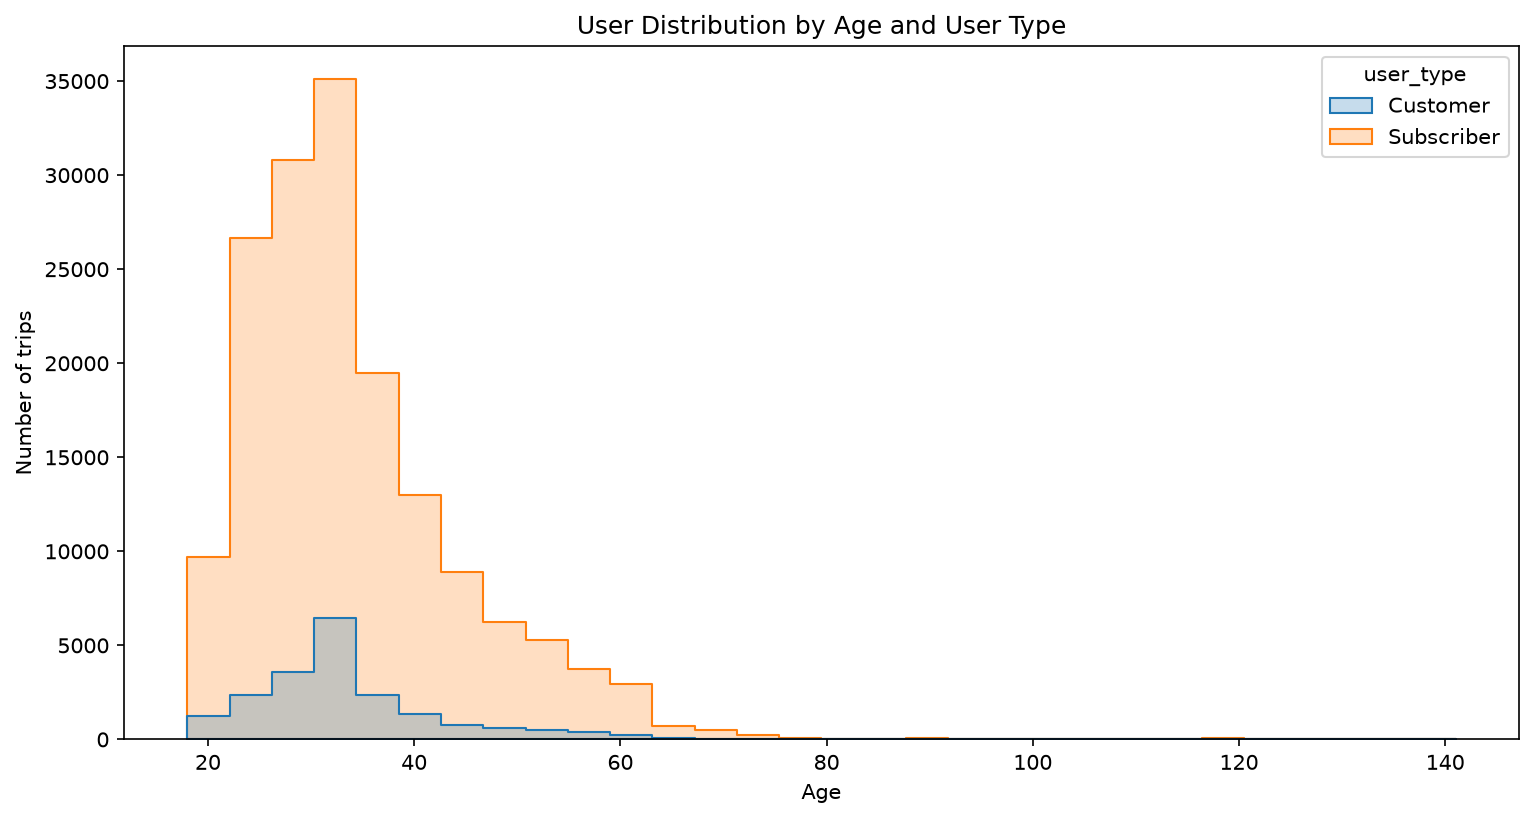

In [48]:
plt.figure(figsize=(12, 6), dpi=150)
sns.histplot(
    data=df,
    x='age',
    hue='user_type',
    bins=30,
    element='step',
    stat='count',
    common_norm=False
)
plt.xlabel("Age")
plt.ylabel("Number of trips")
plt.title("User Distribution by Age and User Type")
plt.show()

> ### <mark>Your analsys and exploration here </mark>
    The age distribution can be compared between Customers and Subscribers The plot shows which age ranges contribute most of the trips for each user type and how the distributions change as age increases.

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

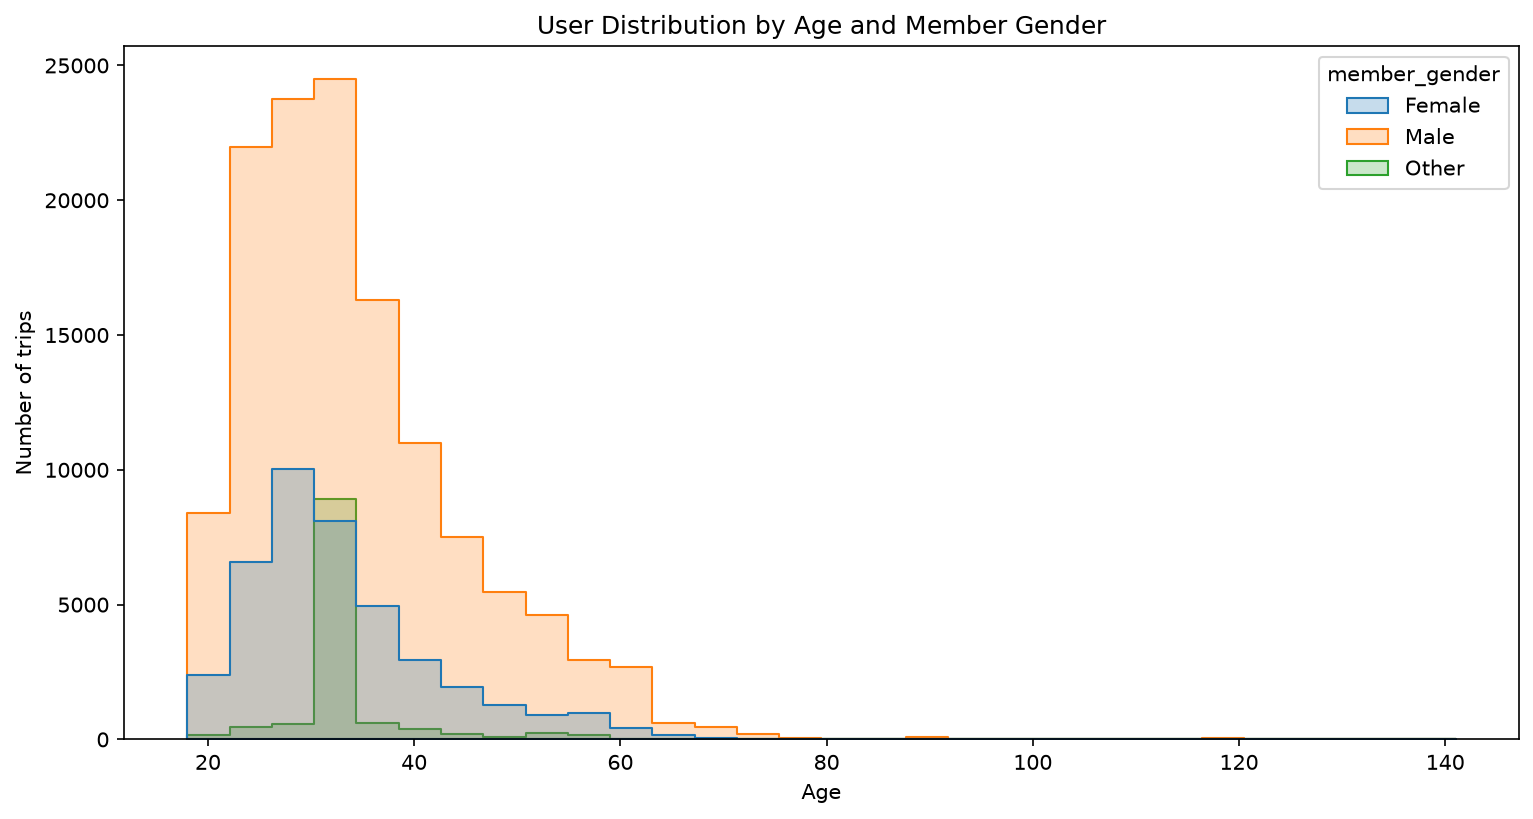

In [49]:
plt.figure(figsize=(12, 6), dpi=150)
sns.histplot(
    data=df,
    x='age',
    hue='member_gender',
    bins=30,
    element='step',
    stat='count',
    common_norm=False
)
plt.xlabel("Age")
plt.ylabel("Number of trips")
plt.title("User Distribution by Age and Member Gender")
plt.show()

> ### <mark>Your analsys and exploration here </mark>
    The age distribution is compared across Male, Female, and Other users. The plot helps identify the age ranges with the highest number of trips for each gender category.


### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Trip duration varies across user types and genders. The age distributions also show that trip frequency is concentrated in particular age ranges rather than being evenly distributed across all ages.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> User type, gender, and age all show different distributions in the dataset. Comparing these variables together gives a clearer picture of user behavior than looking at each variable separately.


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [41]:
## check your work 



# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

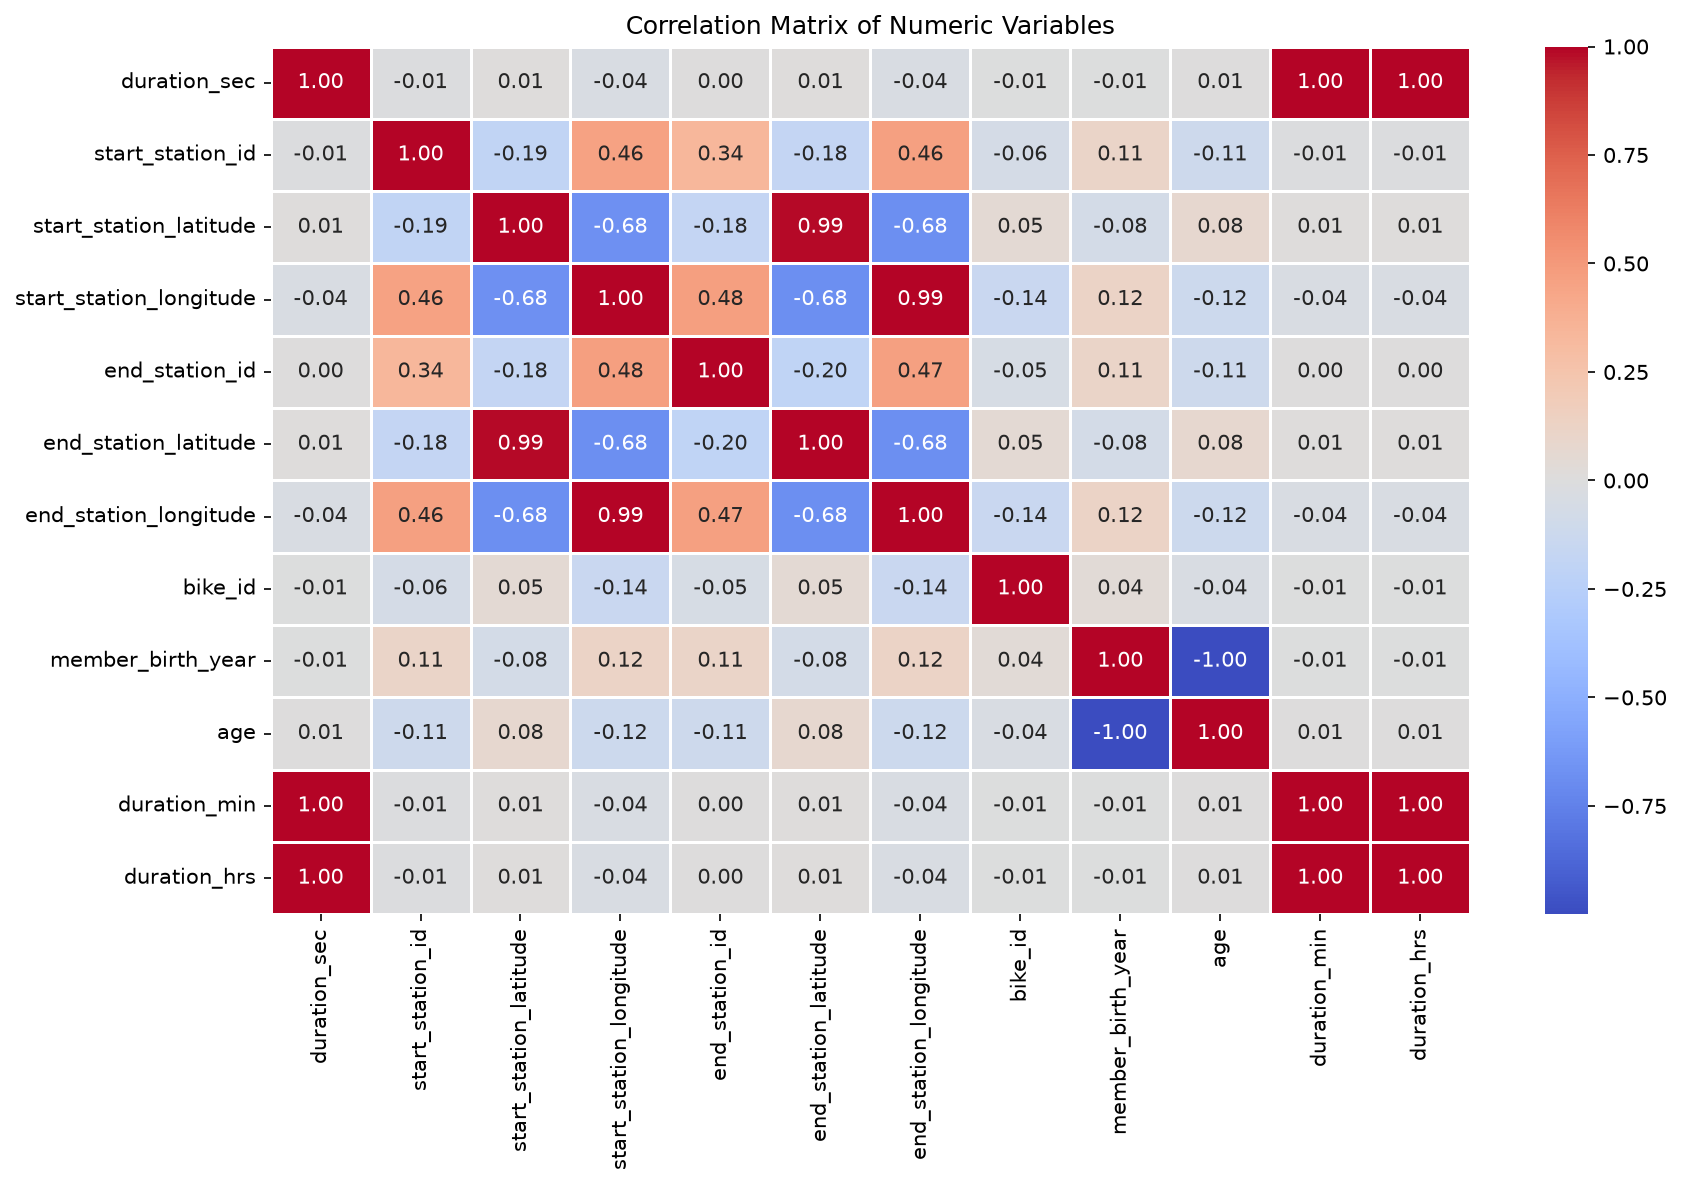

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,age,duration_min,duration_hrs
duration_sec,1.000000,-0.008651,0.010519,-0.037935,0.003062,0.010880,-0.038912,-0.006130,-0.005390,0.005162,1.000000,1.000000
start_station_id,-0.008651,1.000000,-0.189614,0.456149,0.336240,-0.178480,0.463664,-0.064666,0.112319,-0.112249,-0.008651,-0.008651
start_station_latitude,0.010519,-0.189614,1.000000,-0.677254,-0.178445,0.989970,-0.682663,0.050001,-0.075213,0.075136,0.010519,0.010519
start_station_longitude,-0.037935,0.456149,-0.677254,1.000000,0.476532,-0.681840,0.992410,-0.141779,0.124155,-0.123937,-0.037935,-0.037935
end_station_id,0.003062,0.336240,-0.178445,0.476532,1.000000,-0.196568,0.465921,-0.054598,0.109923,-0.109862,0.003062,0.003062
end_station_latitude,0.010880,-0.178480,0.989970,-0.681840,-0.196568,1.000000,-0.684222,0.049249,-0.075313,0.075234,0.010880,0.010880
end_station_longitude,-0.038912,0.463664,-0.682663,0.992410,0.465921,-0.684222,1.000000,-0.143522,0.124969,-0.124748,-0.038912,-0.038912
bike_id,-0.006130,-0.064666,0.050001,-0.141779,-0.054598,0.049249,-0.143522,1.000000,0.035186,-0.035081,-0.006130,-0.006130
member_birth_year,-0.005390,0.112319,-0.075213,0.124155,0.109923,-0.075313,0.124969,0.035186,1.000000,-0.999992,-0.005390,-0.005390
age,0.005162,-0.112249,0.075136,-0.123937,-0.109862,0.075234,-0.124748,-0.035081,-0.999992,1.000000,0.005162,0.005162


In [50]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8), dpi=150)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=.5
)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

display(corr_matrix)



> ### <mark>Your analsys and exploration here </mark>

The correlation matrix shows the linear relationships between the numeric variables in the dataset.

- `duration_sec`, `duration_min`, and `duration_hrs` have an expected perfect positive relationship because they represent the same duration in different units.
- `member_birth_year` and `age` have a strong negative relationship because age was calculated as `2019 - member_birth_year`.
- `bike_id` and station IDs are identifiers, so their correlations should not be interpreted as meaningful behavioral relationships.



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


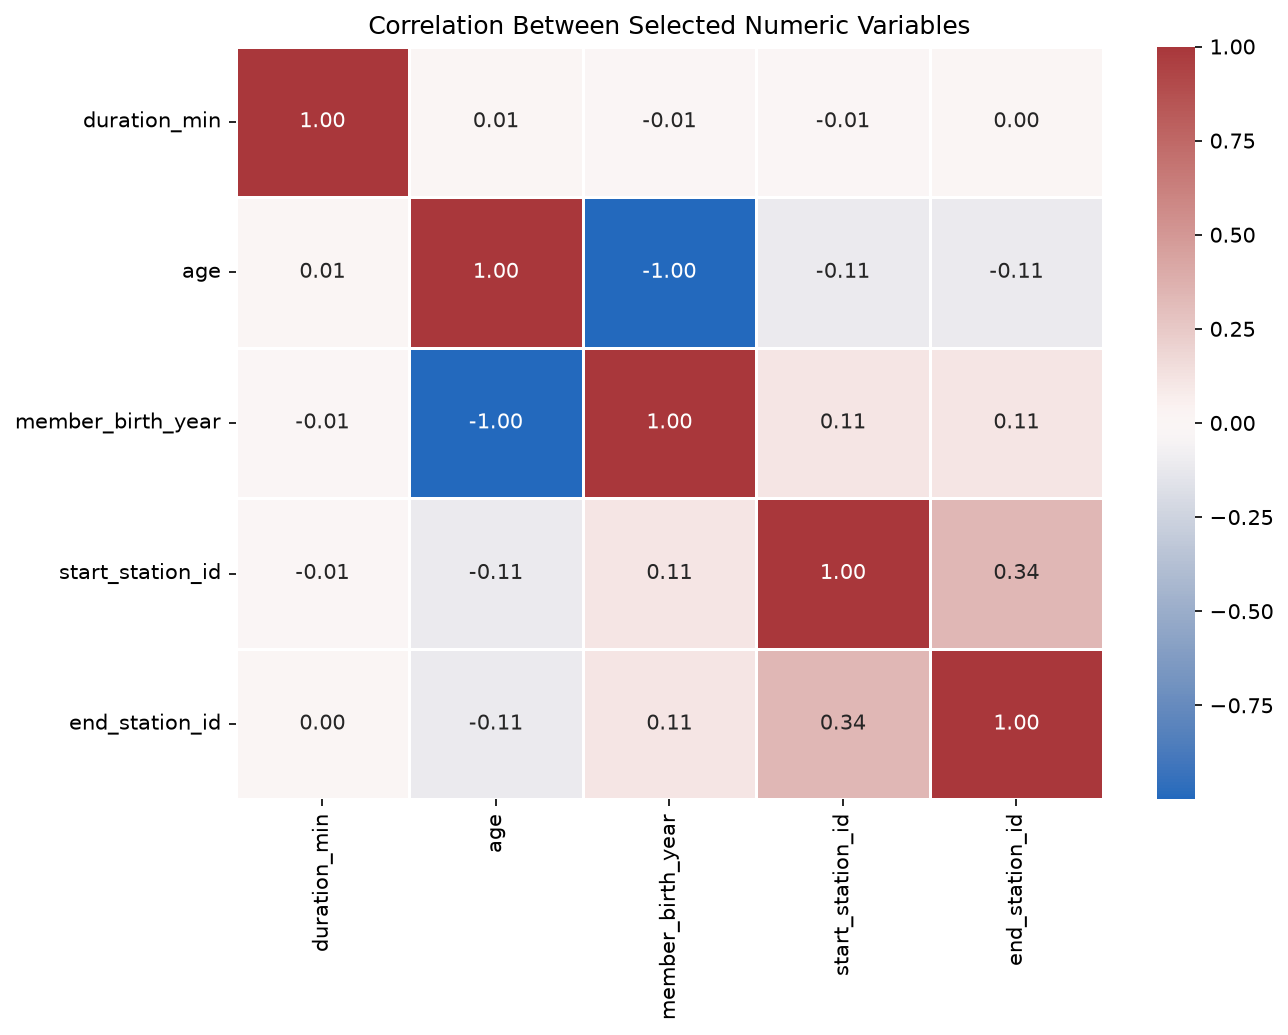

,duration_min,age,member_birth_year,start_station_id,end_station_id
duration_min,1.000000,0.005162,-0.005390,-0.008651,0.003062
age,0.005162,1.000000,-0.999992,-0.112249,-0.109862
member_birth_year,-0.005390,-0.999992,1.000000,0.112319,0.109923
start_station_id,-0.008651,-0.112249,0.112319,1.000000,0.336240
end_station_id,0.003062,-0.109862,0.109923,0.336240,1.000000


In [51]:
selected_numeric = [
    'duration_min',
    'age',
    'member_birth_year',
    'start_station_id',
    'end_station_id'
]

selected_numeric = [c for c in selected_numeric if c in df.columns]
selected_corr = df[selected_numeric].corr()

plt.figure(figsize=(9, 7), dpi=150)
sns.heatmap(
    selected_corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=.5
)
plt.title("Correlation Between Selected Numeric Variables")
plt.tight_layout()
plt.show()

display(selected_corr)



> ### <mark>Your analsys and exploration here </mark>

The selected variables focus on ride duration, age, and station information.

- Duration and age can be compared to investigate whether ride length changes with user age.
- `member_birth_year` is strongly related to `age` because the age variable was derived from birth year.
- Station IDs are identifiers rather than continuous measurements, so any numerical correlation with them should be interpreted cautiously.

# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


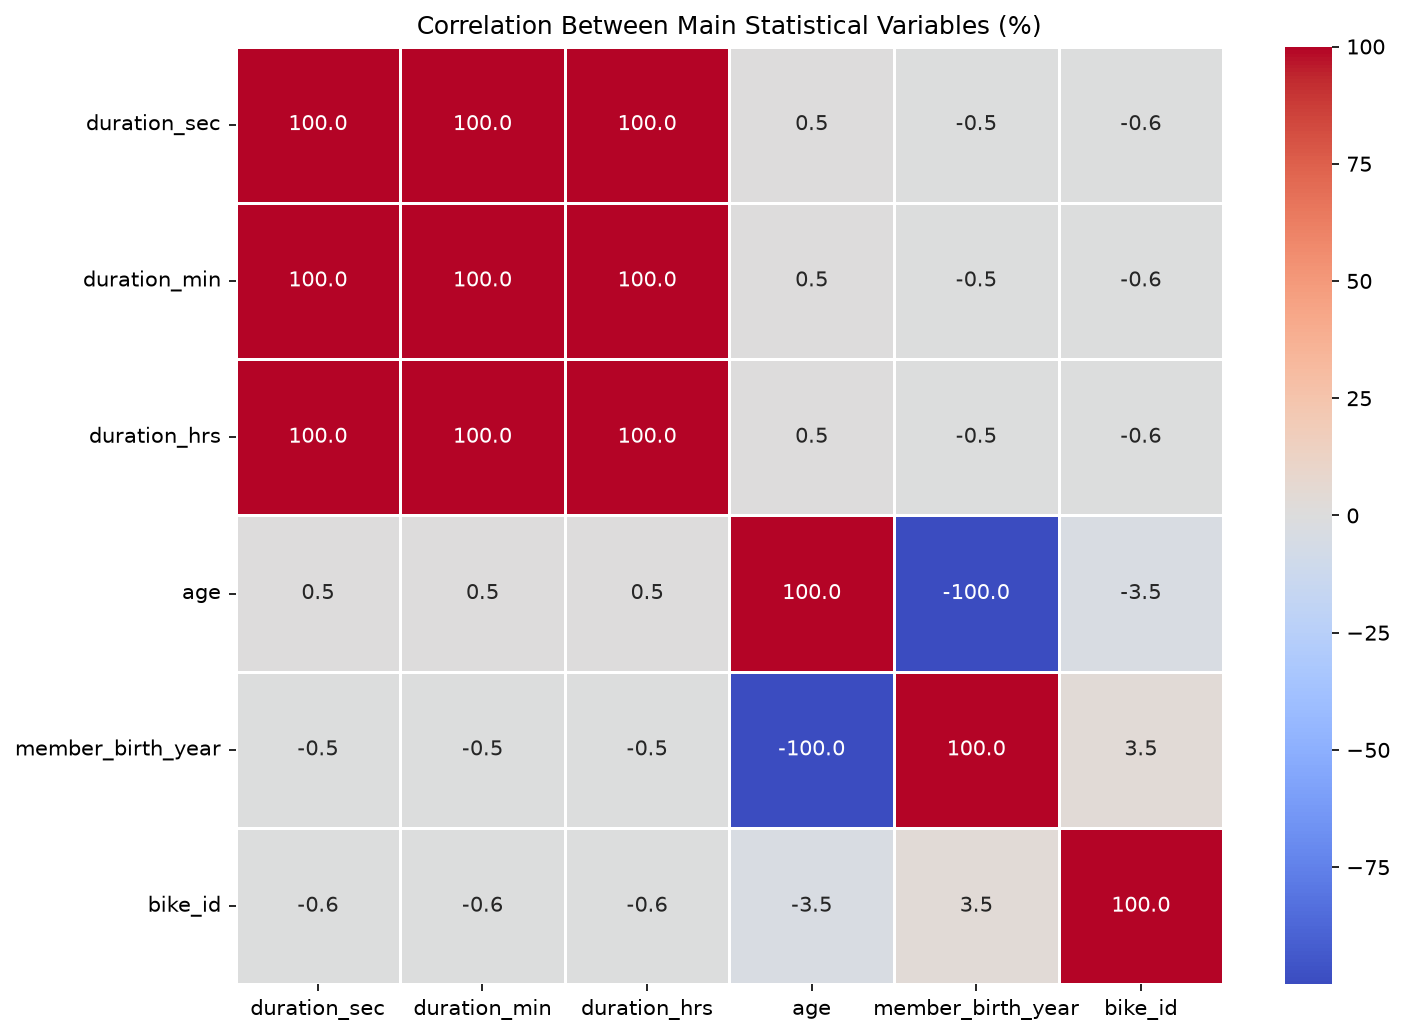

,duration_sec,duration_min,duration_hrs,age,member_birth_year,bike_id
duration_sec,100.000000,100.000000,100.000000,0.516203,-0.538984,-0.613003
duration_min,100.000000,100.000000,100.000000,0.516203,-0.538984,-0.613003
duration_hrs,100.000000,100.000000,100.000000,0.516203,-0.538984,-0.613003
age,0.516203,0.516203,0.516203,100.000000,-99.999176,-3.508089
member_birth_year,-0.538984,-0.538984,-0.538984,-99.999176,100.000000,3.518613
bike_id,-0.613003,-0.613003,-0.613003,-3.508089,3.518613,100.000000


In [52]:
data_stat = df[
    ['duration_sec', 'duration_min', 'duration_hrs',
     'age', 'member_birth_year', 'bike_id']
].copy()

corr_percent = data_stat.corr() * 100

plt.figure(figsize=(10, 7), dpi=150)
sns.heatmap(
    corr_percent,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=.5
)
plt.title("Correlation Between Main Statistical Variables (%)")
plt.tight_layout()
plt.show()

display(corr_percent)




> ### Analysis
The heatmap expresses the correlations as percentages.

- `duration_sec`, `duration_min`, and `duration_hrs` are perfectly positively correlated because they are the same trip-duration measure in different units.
- `member_birth_year` and `age` have a strong negative correlation because age is calculated from birth year.
- `bike_id` is an identifier, so its correlation values do not represent a meaningful behavioral relationship.


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

* Most users in the dataset were Male.

* Subscribers represent the majority of the bike-sharing users, while Customers represent a smaller proportion of the users.

* The average trip duration varies between different user types, which shows that Customers and Subscribers have different usage patterns.

* Trip duration also varies across different gender categories.

* The age distribution shows that users are concentrated in specific age ranges, and the distribution differs between user types and genders.

* The correlation analysis shows strong relationships between `duration_sec`, `duration_min`, and `duration_hrs` because they represent the same trip duration in different units.

* There is a negative correlation between `member_birth_year` and `age`, which is expected because age was calculated from the member birth year.

* `bike_id` does not show a meaningful correlation with the other variables because it is an identifier rather than a measurement.

## Limitations

* The dataset contains missing values. Missing values in station names were replaced with `Unknown`, and missing gender values were replaced with `Other`.

* There were 4 duplicated rows in the dataset.

* Some variables, such as `bike_id` and station IDs, are identifiers, so their numerical correlations should be interpreted carefully.

* The analysis is based on the available variables and data in the dataset, so additional information would be needed to explain other factors that may affect users' trip behavior.
